In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field


In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

# Model
model = ChatGoogleGenerativeAI(model='gemini-3-flash-preview')

C:\Users\manoj\PycharmProjects\LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [3]:
class SentimentSchema(BaseModel):
    sentiment: Literal['positive', 'negative'] = Field(description='Sentiment of the review')

class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [4]:
structured_model = model.with_structured_output(SentimentSchema)

diagnosis_structured_model = model.with_structured_output(DiagnosisSchema)

In [5]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive', 'negative']
    diagnosis: dict
    response: str

In [15]:
def find_sentiment(state: ReviewState):
    prompt = f"Find the sentiment for the following review:\n{state['review']}"
    sentiment = structured_model.invoke(prompt)

    return {"sentiment": sentiment.sentiment}

In [16]:
def check_sentiment(state: ReviewState) -> ReviewState:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'


In [17]:
def positive_response(state: ReviewState) -> ReviewState:
    prompt = f"""
        Write a warm, polite, and professional thank-you message in response to the following customer review:

        "{state['review']}"

        Also:
        - Kindly request the user to share additional feedback on our website
    """
    response = model.invoke(prompt).content

    return {'response': response}

In [18]:
def run_diagnosis(state: ReviewState):

    prompt = f"""
    Analyze the following negative customer review:

    {state['review']}

    Return:
    issue_type
    tone
    urgency
    """

    response = diagnosis_structured_model.invoke(prompt)

    return {"diagnosis": response.model_dump()}


In [19]:
def negative_response(state: ReviewState):

    diagnosis = state["diagnosis"]

    prompt = f"""
    Issue type: {diagnosis['issue_type']}
    Tone: {diagnosis['tone']}
    Urgency: {diagnosis['urgency']}

    Write an empathetic resolution message.
    """

    response = model.invoke(prompt).content

    return {"response": response}

In [20]:
graph = StateGraph(ReviewState)

# Node
graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)


In [21]:
# Edges

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)
graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)


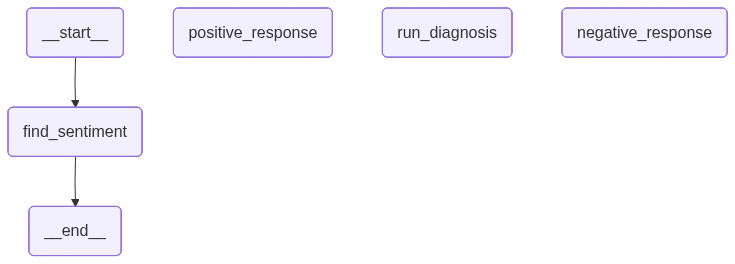

In [22]:
# Compile
workflow = graph.compile()
workflow

In [23]:
initial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(initial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': [{'type': 'text',
   'text': 'Subject: Resolved: Issues with [Feature Name] / Your Support Ticket #[Number]\n\nHi [Customer Name],\n\nI want to start by sincerely apologizing for the frustration this issue has caused you. I completely understand how critical [Feature/System] is to your workflow, and experiencing a total blocker like this—especially when you have a high-priority deadline—is incredibly stressful.\n\nI am reaching out to let you know that our engineering team has successfully deployed a fix, and the issue is now fully resolved.\n\n**What happened:**\nA [brief, non-technical explanation, e.g., configuration update] ca